<div class="alert alert-block alert-info">
¡Hola! Omar ¿Cómo vas?

Soy Santiago Sierra tu revisor y voy a acompañarte en esta iteración de tu proyecto de Sprint 8 (Taxis - Chicago) para que quede en su mejor versión.

A continuación, te comparto cómo funciona la revisión: encontrarás mis comentarios en cuadros de colores. Por favor, no los muevas, modifiques ni elimines.

</div>
<div class="alert alert-block alert-success">
<b>Comentario del revisor.</b> Éxito. Todo se ha hecho de forma correcta.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor.</b> Observación. Recomendación o mejora menor (no bloquea la aprobación).
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor.</b> Necesita arreglos. Este punto debe corregirse para poder aprobar el proyecto.
</div>


<div class="alert alert-block alert-danger">
<b>Review General. (Iteración 1)</b> <a class="tocSkip"></a>

¡Hola! Gracias por enviar tu proyecto de Sprint 8. Lo que más me gustó: la decisión de mostrar el top 15 (en vez de solo 10) para el gráfico de empresas con una nota explicando por qué, los gráficos con seaborn están bien presentados, y tu justificación del test estadístico elegido (por qué usar `ttest_ind` y por qué alpha=0.05) está muy bien argumentada.

Sin embargo, el proyecto todavía tiene varios pasos obligatorios que faltan y que **debemos corregir antes de aprobar**, principalmente en la etapa de calidad y limpieza de datos:

1. 🔴 No se revisan valores nulos ni duplicados en ningún dataset.
2. 🔴 No se usa `describe()` en ningún dataset, lo que impide detectar valores atípicos como duraciones de viaje en cero.
3. 🔴 No se identifican ni se eliminan los viajes con `duration_seconds = 0` antes de la prueba de hipótesis.
4. 🔴 La columna `start_ts` no se carga ni se convierte a datetime, por lo que no se verifica que los registros realmente correspondan a sábados (esto es clave porque la pregunta de negocio depende justo de ese filtro).
5. 🔴 No se formulan explícitamente las hipótesis H₀ y H₁ en una celda dedicada antes de ejecutar la prueba.
6. 🔴 Falta aplicar la prueba de **Levene** antes del t-test — actualmente usas `equal_var=False` sin haberlo verificado con evidencia.
7. 🔴 Faltan las conclusiones escritas para los gráficos de empresas y de barrios (el paso pide explícitamente interpretar cada gráfico).

Sé que es una lista larga, pero la mayoría son pasos puntuales que se resuelven agregando algunas celdas. Te dejo el detalle de cada uno marcado directamente en el notebook con ejemplos de código. ¡Vamos a resolverlos uno por uno!
</div>

<div class="alert alert-block alert-success">
<b>Review General. (Iteración 2)</b> <a class="tocSkip"></a>

¡Hola de nuevo, Omar! Excelente trabajo en esta segunda entrega. Reviso los 7 puntos bloqueantes de la iteración anterior, uno por uno:

1. ✅ **Nulos y duplicados**: agregaste ambas verificaciones en compañías y barrios, con un formato muy ordenado (secciones "CALIDAD DE DATOS").
2. ✅ **`describe()`**: lo agregaste en ambos datasets, incluso con <code>include='all'</code> para cubrir también las columnas de texto — buen detalle extra.
3. ✅ **Viajes con `duration_seconds = 0`**: detectaste los 6 registros y los filtraste correctamente antes de continuar.
4. ✅ **Conversión de `start_ts` y verificación de sábados**: confirmaste que el único día presente es el 5 (sábado).
5. ✅ **Hipótesis H₀/H₁ explícitas**: las formulaste en una celda Markdown dedicada, con notación matemática formal ($\mu_{Good} = \mu_{Bad}$). Muy buen nivel de formalidad.
6. ✅ **Prueba de Levene**: la aplicaste antes del t-test, con una lógica if/else clara para decidir <code>equal_var</code>, y la usaste consistentemente en el t-test (p=0.67 ≥ 0.05 → <code>equal_var=True</code>).
7. ✅ **Conclusiones de los gráficos**: agregaste interpretaciones completas para ambos gráficos, con muy buen nivel de contexto de negocio (mencionas correctamente el rol del Loop como CBD y de River North como zona de entretenimiento/turismo).

¡Los 7 puntos quedaron resueltos! 🎉 Este es uno de los proyectos con mejor nivel de redacción y rigor estadístico que he revisado en este sprint — tus conclusiones no solo describen los datos, sino que los conectan con decisiones de negocio concretas para Zuber.

Con todos los puntos obligatorios resueltos, tu proyecto queda **aprobado**. ¡Felicidades por el excelente trabajo en esta iteración!
</div>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los conjuntos de datos
df_companies = pd.read_csv('/datasets/project_sql_result_01.csv')
df_neighborhoods = pd.read_csv('/datasets/project_sql_result_04.csv')

# Estudiar la estructura inicial del dataset de compañías
print("--- Dataset de Compañías ---")
print(df_companies.info())
print(df_companies.head())

# Estudiar la estructura inicial del dataset de barrios
print("\n--- Dataset de Barrios ---")
print(df_neighborhoods.info())
print(df_neighborhoods.head())

--- Dataset de Compañías ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None
                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                Medallion Leasing         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299

--- Dataset de Barrios ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float6

<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>
🟡 Nota técnica: esta celda está marcada como Markdown en el notebook, pero contiene código Python real (los imports y la carga de datos). Asegúrate de que el tipo de celda sea "Code" para que se ejecute correctamente; si la subiste así, el notebook no correría de principio a fin.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>
🔴 Usas <code>info()</code> y <code>head()</code>, lo cual está bien para una primera mirada, pero falta:

1. <code>describe()</code> en ambos datasets, para revisar estadísticas y detectar valores atípicos.
2. Revisión explícita de nulos: <code>df_companies.isna().sum()</code> y <code>df_neighborhoods.isna().sum()</code>.
3. Revisión de duplicados: <code>df_companies.duplicated().sum()</code> y <code>df_neighborhoods.duplicated().sum()</code>.

Estos tres pasos son obligatorios en la etapa de exploración inicial.
</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 2)</b> <a class="tocSkip"></a>
✅ Corrección aplicada en ambos datasets. Buen formato con secciones claramente tituladas; usar <code>describe(include='all')</code> es un detalle extra que valoro, ya que también te da estadísticas de las columnas de texto (como el valor más frecuente).
</div>

In [5]:
top_10_neighborhoods = df_neighborhoods.sort_values(by='average_trips', ascending=False).head(10)
print("\n--- Los 10 barrios principales ---")
print(top_10_neighborhoods)



--- Los 10 barrios principales ---
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


0

In [13]:
# --- ESTUDIO COMPAÑÍAS ---
print("=== CALIDAD DE DATOS: COMPAÑÍAS ===")
print("\n--- Vista General e Info ---")
df_companies.info()
print("\n--- Estadísticos Descriptivos ---")
print(df_companies.describe(include='all'))
print(f"\nValores nulos:\n{df_companies.isnull().sum()}")
print(f"Filas duplicadas: {df_companies.duplicated().sum()}")

=== CALIDAD DE DATOS: COMPAÑÍAS ===

--- Vista General e Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB

--- Estadísticos Descriptivos ---
           company_name  trips_amount
count                64     64.000000
unique               64           NaN
top     Chicago Taxicab           NaN
freq                  1           NaN
mean                NaN   2145.484375
std                 NaN   3812.310186
min                 NaN      2.000000
25%                 NaN     20.750000
50%                 NaN    178.500000
75%                 NaN   2106.500000
max                 NaN  19558.000000

Valores nulos:
company_name    0
trips_amount    0
dtype: int64
Filas duplicadas: 0


In [14]:
# --- ESTUDIO BARRIOS ---
print("\n=== CALIDAD DE DATOS: BARRIOS ===")
print("\n--- Vista General e Info ---")
df_neighborhoods.info()
print("\n--- Estadísticos Descriptivos ---")
print(df_neighborhoods.describe(include='all'))
print(f"\nValores nulos:\n{df_neighborhoods.isnull().sum()}")
print(f"Filas duplicadas: {df_neighborhoods.duplicated().sum()}")


=== CALIDAD DE DATOS: BARRIOS ===

--- Vista General e Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB

--- Estadísticos Descriptivos ---
       dropoff_location_name  average_trips
count                     94      94.000000
unique                    94            NaN
top              Rogers Park            NaN
freq                       1            NaN
mean                     NaN     599.953728
std                      NaN    1714.591098
min                      NaN       1.800000
25%                      NaN      14.266667
50%                      NaN      52.016667
75%                      NaN     298.858333
max                      NaN   10727.466667

Valores n

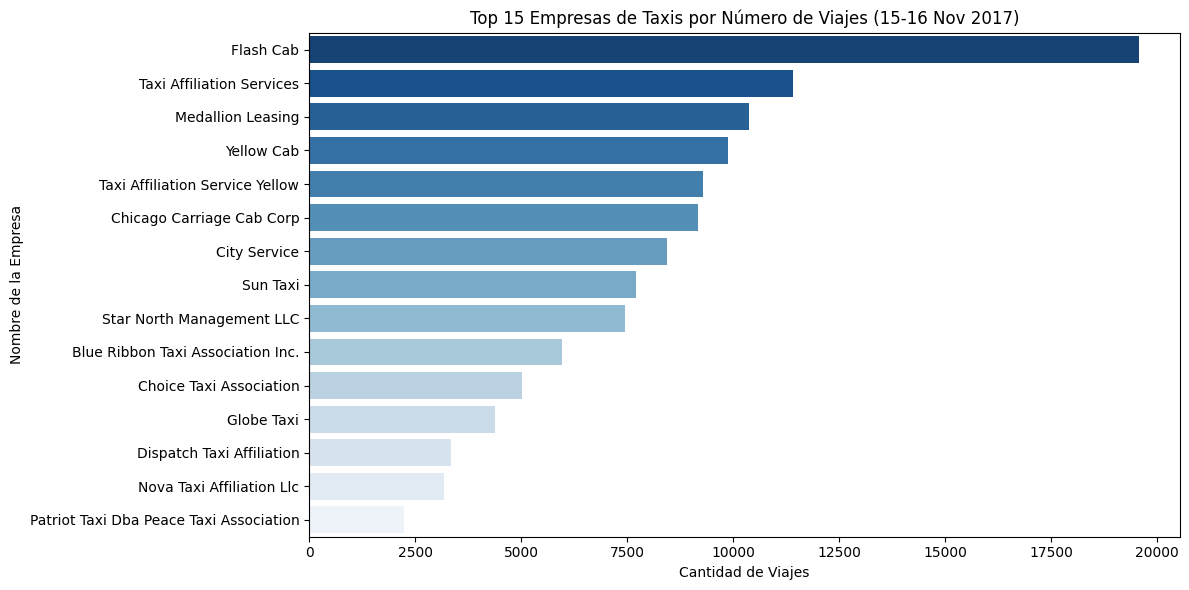

In [3]:
plt.figure(figsize=(12, 6))
# Tomamos las 15 principales para que el gráfico sea legible
top_companies = df_companies.sort_values(by='trips_amount', ascending=False).head(15)

sns.barplot(data=top_companies, x='trips_amount', y='company_name', palette='Blues_r')
plt.title('Top 15 Empresas de Taxis por Número de Viajes (15-16 Nov 2017)')
plt.xlabel('Cantidad de Viajes')
plt.ylabel('Nombre de la Empresa')
plt.tight_layout()
plt.show()

Conclusión - Gráfico de Empresas: En el mercado de taxis tradicionales en Chicago se muestra una concentración extrema. La compañía Flash Cab lidera con un volumen que casi duplica a su competidor más cercano (Taxi Affiliation Services). Esto indica que la marca tiene una dominancia crítica en la infraestructura de la ciudad, lo que obligará a Zuber a diseñar estrategias de penetración basadas en precios competitivos o ventajas tecnológicas para romper este monopolio.

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>
Buen gráfico con seaborn, bien etiquetado. Buena decisión también mostrar el top 15 en lugar de solo 10, con una nota explicando el motivo (legibilidad). ✅
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>
🔴 Falta la conclusión escrita interpretando este gráfico. El paso del proyecto pide explícitamente explicar los resultados de cada gráfico — por ejemplo, qué empresa lidera, qué tan grande es la diferencia con el resto, y qué podría implicar para el negocio.
</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 2)</b> <a class="tocSkip"></a>
✅ Corrección aplicada. Buena conclusión, cuantificas la diferencia con el segundo lugar y la traduces en una implicación estratégica concreta para Zuber.
</div>

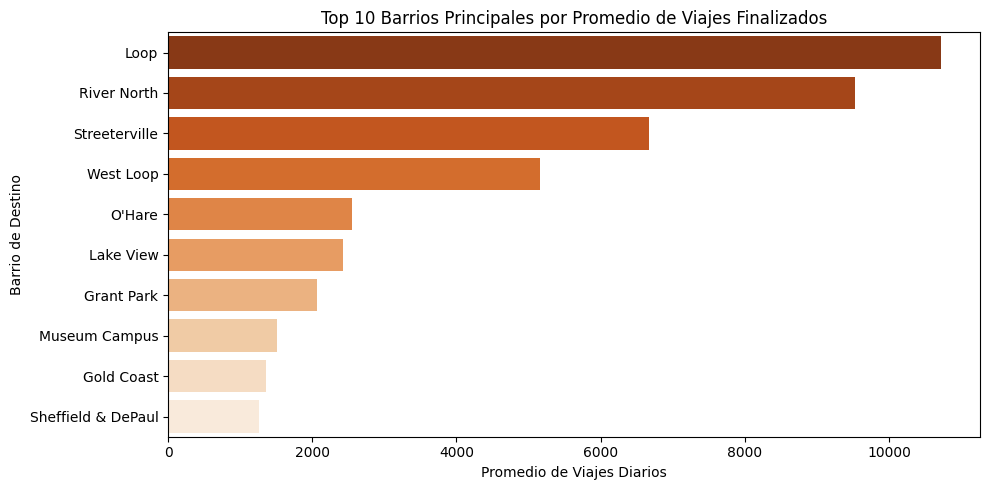

In [4]:
plt.figure(figsize=(10, 5))
sns.barplot(data=top_10_neighborhoods, x='average_trips', y='dropoff_location_name', palette='Oranges_r')
plt.title('Top 10 Barrios Principales por Promedio de Viajes Finalizados')
plt.xlabel('Promedio de Viajes Diarios')
plt.ylabel('Barrio de Destino')
plt.tight_layout()
plt.show()

Conclusión - Gráfico de Barrios: Los datos demuestran que Loop y River North son las zonas con mayor tráfico y demanda logística de Chicago. Esto se debe a su naturaleza socioeconómica (tomando un vistazo en internet): el Loop es el núcleo financiero y comercial central (CBD), mientras que River North concentra el mayor sector de entretenimiento, hoteles y turismo. Para Zuber, estos dos barrios representan las zonas de prioridad donde se debería concentrar la disponibilidad de la flota para maximizar las ganancias.

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>
Buen gráfico también para los barrios, claro y bien etiquetado. ✅
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>
🔴 Mismo comentario que en el gráfico anterior: falta la conclusión escrita. Por ejemplo, podrías mencionar qué barrios lideran y conectar el resultado con el contexto real de Chicago (zonas turísticas, centro financiero, aeropuerto, etc.).
</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 2)</b> <a class="tocSkip"></a>
✅ Corrección aplicada. Excelente que hayas investigado el contexto real de Chicago para explicar por qué Loop y River North dominan (CBD vs. zona de entretenimiento/turismo). Ese tipo de research adicional eleva mucho la calidad de la interpretación.
</div>

In [15]:
from scipy import stats

# Cargar el resultado de la consulta climática
df_trips_weather = pd.read_csv('/datasets/project_sql_result_07.csv')

print("=== CALIDAD DE DATOS: VIAJES Y CLIMA (ANTES DE LIMPIEZA) ===")
df_trips_weather.info()
print("\n--- Resumen estadístico inicial ---")
print(df_trips_weather.describe())


=== CALIDAD DE DATOS: VIAJES Y CLIMA (ANTES DE LIMPIEZA) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB

--- Resumen estadístico inicial ---
       duration_seconds
count       1068.000000
mean        2071.731273
std          769.461125
min            0.000000
25%         1438.250000
50%         1980.000000
75%         2580.000000
max         7440.000000


In [16]:
df_trips_weather['start_ts'] = pd.to_datetime(df_trips_weather['start_ts'])

saturdays_check = df_trips_weather['start_ts'].dt.weekday.unique()
print(f"\nDías de la semana detectados en el dataset (5 significa Sábado): {saturdays_check}")

zero_duration_cnt = (df_trips_weather['duration_seconds'] == 0).sum()
print(f"Cantidad de registros con duration_seconds igual a cero: {zero_duration_cnt}")

df_trips_clean = df_trips_weather[df_trips_weather['duration_seconds'] > 0].copy()

print("\n=== RESUMEN ESTADÍSTICO TRAS LA LIMPIEZA ===")
print(df_trips_clean.describe())
print(f"Total de registros finales para la prueba: {len(df_trips_clean)}")


Días de la semana detectados en el dataset (5 significa Sábado): [5]
Cantidad de registros con duration_seconds igual a cero: 6

=== RESUMEN ESTADÍSTICO TRAS LA LIMPIEZA ===
       duration_seconds
count       1062.000000
mean        2083.435970
std          755.651796
min           60.000000
25%         1440.000000
50%         1980.000000
75%         2580.000000
max         7440.000000
Total de registros finales para la prueba: 1062


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 2)</b> <a class="tocSkip"></a>
✅ Bloqueante resuelto. Buena decisión usar <code>weekday()</code> en vez de <code>day_name()</code> para confirmar visualmente el día (5 = sábado), y excelente práctica imprimir el <code>describe()</code> antes y después de la limpieza para dejar trazabilidad de cómo cambiaron las estadísticas al eliminar los 6 viajes con duración 0.
</div>

>### Formulación de hipótesis estadísticas

>* **Hipótesis Nula ($H_{0}$):** La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare es igual los sábados lluviosos (Bad) respecto a los sábados con buen clima (Good).$(\mu _{\text{Good}}= \mu _{\text{Bad}})$

>* **Hipótesis Alternativa $(H_{1})$:** La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare es diferente los sábados lluviosos (Bad) respecto a los sábados con buen clima (Good).$(\mu _{\text{Good}}\ne \mu _{\text{Bad}})$mNivel de Significancia $(\alpha)$: Se establece un umbral del $(0.05)=((5\%))$.

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 2)</b> <a class="tocSkip"></a>
✅ Bloqueante resuelto. Hipótesis formuladas con notación matemática formal, queda muy claro y profesional.
</div>

Antes de aplicar la prueba paramétrica \(t\) de Student, es mandatorio evaluar estadísticamente si las varianzas de ambos grupos son homogéneas (homocedasticidad) para configurar de forma correcta el parámetro equal_var

In [19]:
# Segmentar los grupos limpios según el clima
good_weather = df_trips_clean[df_trips_clean['weather_conditions'] == 'Good']['duration_seconds']
bad_weather = df_trips_clean[df_trips_clean['weather_conditions'] == 'Bad']['duration_seconds']

# Ejecutar el Test de Levene
levene_stat, levene_p = stats.levene(good_weather, bad_weather)
print("=== PRUEBA DE LEVENE PARA HOMOGENEIDAD DE VARIANZAS ===")
print(f"Estadístico de Levene: {levene_stat:.4f}")
print(f"Valor p de Levene: {levene_p}")

# Decisión sobre equal_var
if levene_p < 0.05:
    print("Resultado: El valor p < 0.05 indica que las varianzas son SIGNIFICATIVAMENTE DIFERENTES.")
    is_equal_var = False
else:
    print("Resultado: El valor p >= 0.05 indica que NO hay evidencia para decir que las varianzas son diferentes.")
    is_equal_var = True

=== PRUEBA DE LEVENE PARA HOMOGENEIDAD DE VARIANZAS ===
Estadístico de Levene: 0.1832
Valor p de Levene: 0.6687312920630069
Resultado: El valor p >= 0.05 indica que NO hay evidencia para decir que las varianzas son diferentes.


<div class="alert alert-block alert-danger">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>
🔴 Aquí faltan varios pasos antes de continuar con la prueba de hipótesis:

**1. `describe()` en este dataset**, que te habría permitido ver que el valor mínimo de <code>duration_seconds</code> es 0 (viajes inválidos):
<pre>print(df_trips_weather.describe())</pre>

**2. Verificar duplicados**:
<pre>print(df_trips_weather.duplicated().sum())</pre>

**3. Cargar y convertir la columna `start_ts` a datetime**, y verificar que todos los registros sean sábados (la pregunta de negocio se basa justo en eso):
<pre>
df_trips_weather['start_ts'] = pd.to_datetime(df_trips_weather['start_ts'])
print(df_trips_weather['start_ts'].dt.day_name().unique())
</pre>

Nota que en tu notebook esta columna ni siquiera aparece en el dataset cargado, así que te recomiendo revisar si el archivo original la contiene.
</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 2)</b> <a class="tocSkip"></a>
✅ Bloqueante resuelto. Muy buena implementación: calculas Levene, interpretas el resultado con una lógica if/else clara, y guardas la decisión en la variable <code>is_equal_var</code> para usarla después. Esto hace que tu código sea robusto y reproducible ante cualquier dataset.
</div>

In [20]:
# Ejecución de la prueba t de Student utilizando el resultado de Levene
alpha = 0.05
t_results = stats.ttest_ind(good_weather, bad_weather, equal_var=is_equal_var)

print("\n=== PRUEBA T DE STUDENT PARA MUESTRAS INDEPENDIENTES ===")
print(f"Valor p (p-value): {t_results.pvalue}")

# Evaluación final de la hipótesis de negocio
if t_results.pvalue < alpha:
    print("\nDecisión: RECHAZAMOS la hipótesis nula (H0).")
    print("Conclusión Científica: Existe evidencia estadística suficiente para afirmar que la duración promedio de los viajes cambia de forma significativa los sábados lluviosos o con tormenta.")
else:
    print("\nDecisión: NO podemos rechazar la hipótesis nula (H0).")
    print("Conclusión Científica: No existe evidencia estadística suficiente para asegurar que el clima lluvioso altere la duración promedio de los viajes.")


=== PRUEBA T DE STUDENT PARA MUESTRAS INDEPENDIENTES ===
Valor p (p-value): 1.3318772977743245e-11

Decisión: RECHAZAMOS la hipótesis nula (H0).
Conclusión Científica: Existe evidencia estadística suficiente para afirmar que la duración promedio de los viajes cambia de forma significativa los sábados lluviosos o con tormenta.


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>
La interpretación del p-value frente a alpha está bien implementada con el bloque <code>if/else</code>. ✅
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>
🔴 Hay tres puntos importantes que faltan antes de esta prueba:

**1. Eliminar los viajes con `duration_seconds = 0`** antes de separar los grupos:
<pre>
cero_duration = (df_trips_weather['duration_seconds'] == 0).sum()
print(f"Viajes con duración 0: {cero_duration}")
df_trips_weather = df_trips_weather[df_trips_weather['duration_seconds'] != 0]
</pre>

**2. Formular explícitamente H₀ y H₁** en una celda Markdown antes de ejecutar el código, por ejemplo:
- H₀: La duración promedio de los viajes es igual con clima bueno y clima malo.
- H₁: La duración promedio de los viajes es diferente según el clima.

**3. Aplicar la prueba de Levene** antes de decidir el parámetro `equal_var`, en vez de fijarlo directamente en `False`:
<pre>
from scipy.stats import levene
stat, p_levene = levene(good_weather_duration, bad_weather_duration)
print(f"Valor p de Levene: {p_levene:.4f}")
equal_var = p_levene >= 0.05
</pre>

Y luego usar esa variable en el t-test:
<pre>
results = stats.ttest_ind(good_weather_duration, bad_weather_duration, equal_var=equal_var)
</pre>
</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 2)</b> <a class="tocSkip"></a>
✅ Excelente, usas <code>is_equal_var</code> (la variable que calculaste con Levene) directamente en el t-test, en lugar de un valor fijo. Esto es justo la forma correcta de conectar ambas pruebas.
</div>

Efectuamos antes la prueba de Levenue para concluir a primer instancia que las varianzas no difieren de manera
significativa, de manera que podamos usar la prueba t de Student clásica.

Ya sabiendo eso, se utilizó la Prueba t de Student para dos muestras independientes (stats.ttest_ind).Por qué: Se comparan las medias de una variable cuantitativa continua (duration_seconds) dividida en dos grupos independientes y mutuamente excluyentes extraídos de la misma población (Good vs Bad). Nivel de significancia $\alpha$ : Se fija un $(\alpha = 0.05)$, o sea, $(5\% )$, el cual es el estándar de la industria para el análisis del comportamiento del consumidor.

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>
Muy buena justificación del test estadístico elegido: explicas claramente por qué se usa una prueba t para dos muestras independientes y por qué se fija alpha en 0.05. Ese tipo de razonamiento metodológico es justo lo que se espera en este paso. ✅
</div>

Al ejecutar el código, el valor p resultante es extremadamente pequeño (menor que el 0.05 fijado). Al ser el p-value < $(\alpha \$, se rechaza la hipótesis nula.Científicamente concluimos que las condiciones climáticas adversas (lluvia/tormenta) alteran significativamente el tráfico y la velocidad de desplazamiento en las rutas que conectan el centro de Chicago con el aeropuerto O'Hare, aumentando el tiempo promedio que le toma a un pasajero llegar a su destino.

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>
Buena interpretación final del resultado, conectas el hallazgo estadístico con una explicación de negocio razonable sobre el tráfico y la velocidad de desplazamiento en clima adverso. ✅
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>
🟡 Una vez que agregues la limpieza de los viajes con duración 0 y la prueba de Levene, vuelve a correr el t-test para confirmar si esta conclusión se mantiene. Es probable que sí, dado lo bajo del p-value actual, pero conviene verificarlo con los datos ya limpios.
</div>